Running two unbiased simulation for site A and B of alanine dipeptide

## Setup

In [58]:
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import plumed

In [59]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
#NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions
STRIDE      = 100

num_steps   = NUM_STEPS

os.chdir(BASE_DIR)

In [44]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [60]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.* COLVAR KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

## 1.0 Unbiased simulations in the metastable states

First, we perform short MD simulations starting from the two snapshots of the molecule, and characterizing each state with a set of descriptors. To proceed in a blind way, we choose to use as input features all the distances between heavy atoms (the list of such descriptors are in the file `plumed-distances.dat`).

**State A**

In [63]:
# CREATE FOLDER AND COPY INPUTS
folderA = DATA_DIR / "0_unbiased-sA/"
Path(folderA).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderA)
execute(f"cp {MD_IN_DIR}/input.tpr .", folderA)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [64]:
# WRITE PLUMED INPUT FILE
with open(folderA / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [69]:
clean(folderA) # note: this deletes all previous results in folder!

In [ ]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} > alanine.out", folder=folderA)

In [67]:
# print command to run in terminal (for longer run)

print(f"cd {folderA}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/0_unbiased-sA
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 500000 -v


**State B**

In [70]:
# CREATE FOLDER AND COPY INPUTS
folderB = DATA_DIR / "0_unbiased-sB/"
Path(folderB).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderB)
execute(f"cp {MD_IN_DIR}/input.sB.tpr input.tpr", folderB)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.sB.tpr input.tpr


In [71]:
# WRITE PLUMED INPUT FILE
with open(folderB / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [72]:
clean(folderB) # note: this deletes all previous results in folder!

In [ ]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} > alanine.out", folder=folderB)

In [73]:
# print command to run in terminal (for longer run)

print(f"cd {folderB}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/0_unbiased-sB
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 500000 -v


### Analize simulations

Ramachandran plot of the two simulations

σ(φ) State A: 0.5561 rad
σ(φ) State B: 0.1362 rad


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/dani/plumed-2.10.0/src/lib/install/libplumedKernel.so" +++


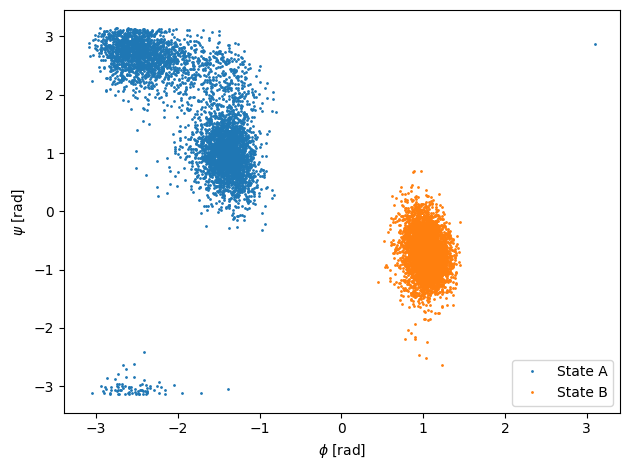

In [74]:
# import PLUMED COLVAR files into pandas datasets
dataA = plumed.read_as_pandas(str(folderA / "COLVAR"))
dataB = plumed.read_as_pandas(str(folderB / "COLVAR"))
# plot phi vs psi
fig, ax = plt.subplots()
ax.plot(dataA["phi"], dataA["psi"], 'o', ms=1, label="State A")
ax.plot(dataB["phi"], dataB["psi"], 'o', ms=1, label="State B")
ax.set_xlabel(r"$\phi$ [rad]")
ax.set_ylabel(r"$\psi$ [rad]")
ax.legend()
plt.tight_layout()

# calculate gaussian sigma
for label, data in [("A", dataA), ("B", dataB)]:
    print(f"σ(φ) State {label}: {np.std(data['phi']):.4f} rad")